<a href="https://colab.research.google.com/github/salianvikram/Predictive-Indoor-Outdoor-Air-Quality-Control-System/blob/main/RF_PM2_5%2C_PM10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.
Memory cleanup completed.

Dataset loaded successfully.
Dataset shape: (1048575, 5)

Dataset columns:
['StationId', 'Datetime', 'PM2.5', 'PM10', 'AQI']

First 5 rows:
  StationId          Datetime  PM2.5    PM10  AQI
0     AP001  24-11-2017 17:00  60.50   98.00  NaN
1     AP001  24-11-2017 18:00  65.50  111.25  NaN
2     AP001  24-11-2017 19:00  80.00  132.00  NaN
3     AP001  24-11-2017 20:00  81.50  133.25  NaN
4     AP001  24-11-2017 21:00  75.25  116.00  NaN

All required columns are available.

Datetime conversion completed.

Numeric conversion completed.

Dataset sorted chronologically.

Missing values handled.

Time features created.

Cyclic time features created.

PM2.5 lag features created.

PM10 lag features created.

AQI lag features created.

PM2.5 rolling features created.

PM10 rolling features created.

AQI rolling features created.

Next-hour AQI target created.

Total number of features: 39

Rows after removing missing values: 1048550



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:  3.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



Random Forest training completed.

Generating predictions...


[Parallel(n_jobs=2)]: Done  30 out of  30 | elapsed:    0.3s finished


Predictions generated.


RANDOM FOREST MODEL PERFORMANCE
MAE  : 48.66
MSE  : 4384.16
RMSE : 66.21
R²   : 0.5745


MODEL INFORMATION
Algorithm       : Random Forest Regressor
Target          : Next-Hour AQI
Input pollutants: PM2.5, PM10
Number of trees : 30
Maximum depth   : 12
Minimum leaf    : 5
Training rows   : 250000
Testing rows    : 171870
Total features  : 39


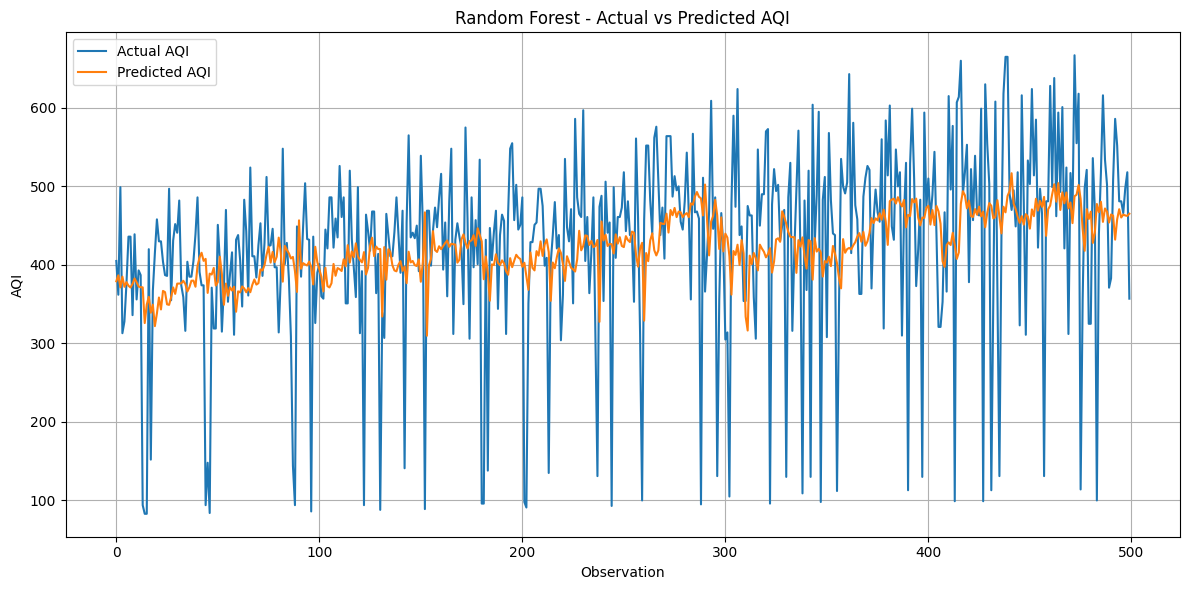

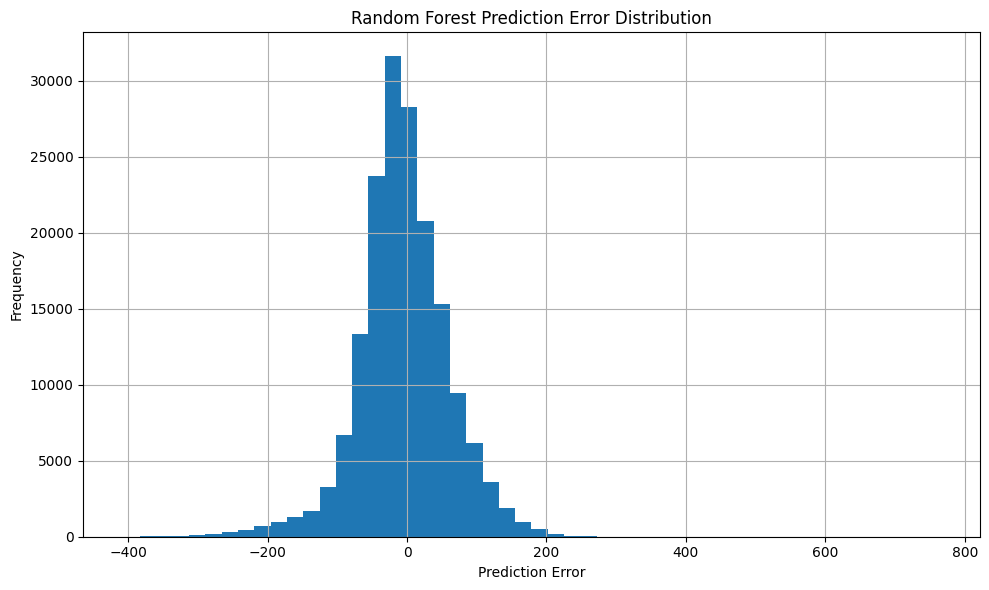

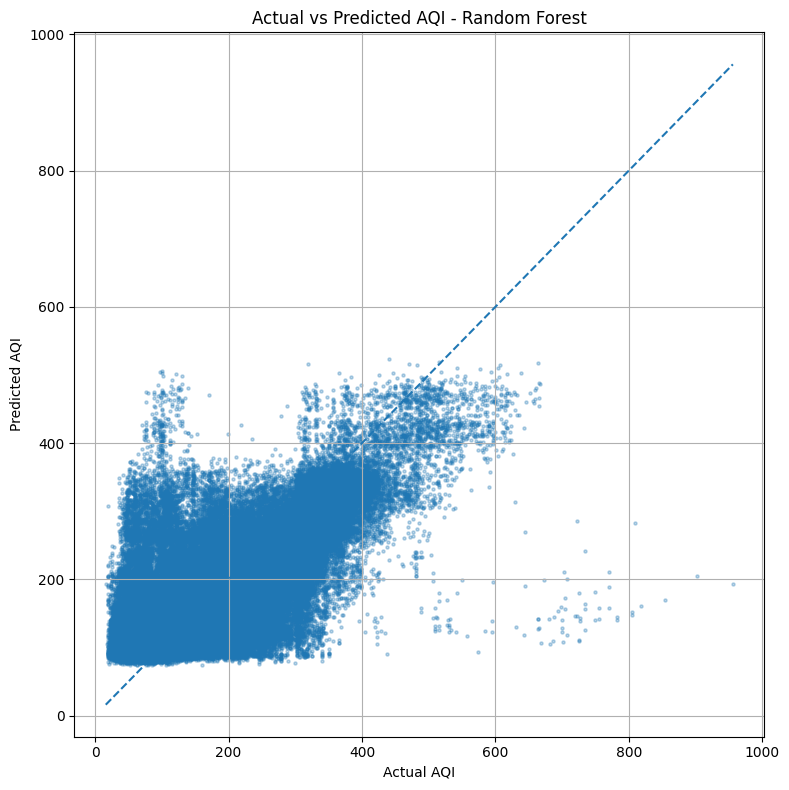



TOP 15 FEATURE IMPORTANCES
       Feature  Importance
AQI_rolling_24    0.895512
     AQI_lag_1    0.015036
         PM2.5    0.011616
          PM10    0.006412
          Year    0.005151
    AQI_lag_24    0.004816
 AQI_rolling_6    0.004737
 AQI_rolling_3    0.004090
    AQI_lag_12    0.003998
     AQI_lag_6    0.003428
     AQI_lag_3    0.002915
   PM2.5_lag_1    0.002505
    PM10_lag_1    0.002443
   PM10_lag_24    0.002394
   PM10_lag_12    0.002281


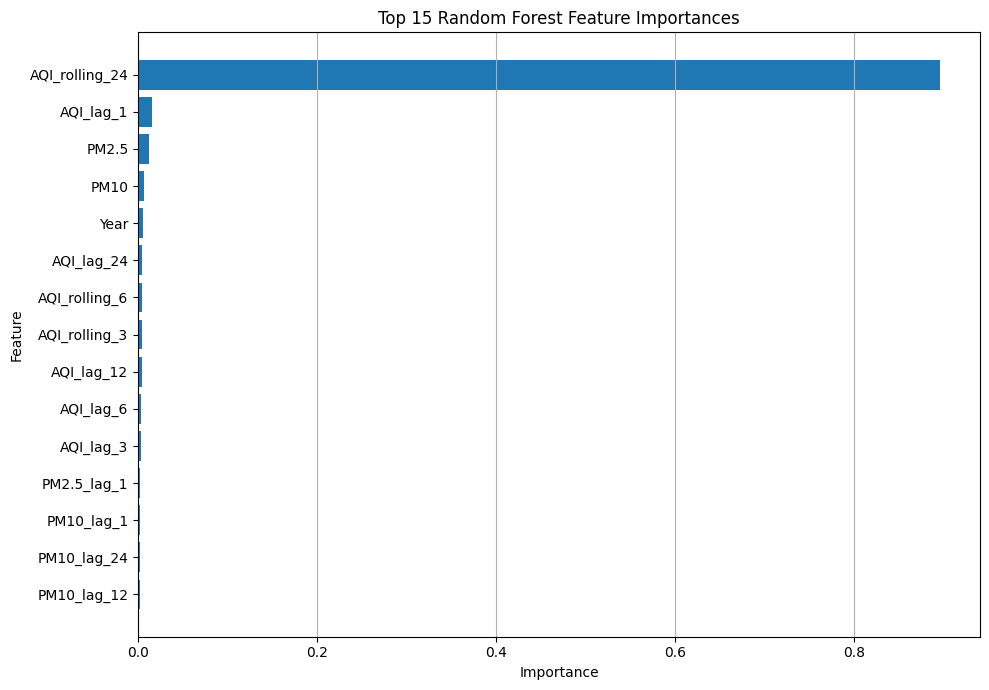


Model saved successfully:
AQI_RandomForest_PM_Model.pkl

Feature list saved successfully:
AQI_RandomForest_PM_Features.pkl

Feature importance saved successfully:
AQI_RandomForest_Feature_Importance.csv


SAMPLE PREDICTIONS
    Actual_AQI  Predicted_AQI  Absolute_Error
0        405.0         379.18           25.82
1        362.0         386.77           24.77
2        499.0         371.38          127.62
3        313.0         385.10           72.10
4        328.0         372.10           44.10
5        376.0         377.99            1.99
6        436.0         373.43           62.57
7        436.0         371.22           64.78
8        336.0         375.93           39.93
9        439.0         382.74           56.26
10       356.0         377.82           21.82
11       393.0         372.36           20.64
12       387.0         371.58           15.42
13        94.0         371.44          277.44
14        83.0         325.92          242.92
15        83.0         349.52          

In [3]:
# ============================================================
# AQI PREDICTION USING RANDOM FOREST
#
# DATASET:
# station_hour_pm_aqi.csv
#
# AVAILABLE COLUMNS:
# Datetime
# PM2.5
# PM10
# AQI
#
# MODEL:
# Random Forest Regressor
#
# TARGET:
# NEXT-HOUR AQI
#
# OPTIMIZED FOR:
# Google Colab
# Large Dataset
# Lower RAM Usage
# Faster Training
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import gc

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")


# ============================================================
# 2. MEMORY CLEANUP
# ============================================================

gc.collect()

print("Memory cleanup completed.")


# ============================================================
# 3. LOAD DATASET
# ============================================================

FILE_NAME = "station_hour_pm_aqi (1).csv"

df = pd.read_csv(

    FILE_NAME,

    dtype={
        "PM2.5": np.float32,
        "PM10": np.float32,
        "AQI": np.float32
    }

)

print("\nDataset loaded successfully.")

print(
    "Dataset shape:",
    df.shape
)


# ============================================================
# 4. DISPLAY DATASET INFORMATION
# ============================================================

print("\nDataset columns:")

print(
    df.columns.tolist()
)


print("\nFirst 5 rows:")

print(
    df.head()
)


# ============================================================
# 5. CLEAN COLUMN NAMES
# ============================================================

df.columns = (

    df.columns
    .str.strip()

)


# ============================================================
# 6. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [

    "Datetime",
    "PM2.5",
    "PM10",
    "AQI"

]


missing_columns = [

    col

    for col in required_columns

    if col not in df.columns

]


if len(missing_columns) > 0:

    raise ValueError(

        "Missing required columns: "
        + str(missing_columns)

    )


print(
    "\nAll required columns are available."
)


# ============================================================
# 7. CONVERT DATETIME
# ============================================================

df["Datetime"] = pd.to_datetime(

    df["Datetime"],

    format="%d-%m-%Y %H:%M",

    errors="coerce"

)


# Remove invalid dates

df = df.dropna(

    subset=["Datetime"]

)


print(
    "\nDatetime conversion completed."
)


# ============================================================
# 8. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [

    "PM2.5",
    "PM10",
    "AQI"

]


for col in numeric_columns:

    df[col] = pd.to_numeric(

        df[col],

        errors="coerce"

    ).astype(
        np.float32
    )


print(
    "\nNumeric conversion completed."
)


# ============================================================
# 9. SORT DATA CHRONOLOGICALLY
# ============================================================

df = (

    df

    .sort_values(

        by="Datetime"

    )

    .reset_index(

        drop=True

    )

)


print(
    "\nDataset sorted chronologically."
)


# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

for col in numeric_columns:

    df[col] = (

        df[col]

        .ffill()

        .bfill()

    )


print(
    "\nMissing values handled."
)


# ============================================================
# 11. CREATE TIME FEATURES
# ============================================================

df["Hour"] = (

    df["Datetime"]

    .dt.hour

)


df["Day"] = (

    df["Datetime"]

    .dt.day

)


df["Month"] = (

    df["Datetime"]

    .dt.month

)


df["DayOfWeek"] = (

    df["Datetime"]

    .dt.dayofweek

)


df["DayOfYear"] = (

    df["Datetime"]

    .dt.dayofyear

)


df["Year"] = (

    df["Datetime"]

    .dt.year

)


df["IsWeekend"] = (

    df["DayOfWeek"] >= 5

).astype(np.int8)


print(
    "\nTime features created."
)


# ============================================================
# 12. CREATE CYCLIC TIME FEATURES
# ============================================================

df["Hour_Sin"] = (

    np.sin(

        2 * np.pi *

        df["Hour"] / 24

    )

).astype(np.float32)


df["Hour_Cos"] = (

    np.cos(

        2 * np.pi *

        df["Hour"] / 24

    )

).astype(np.float32)


df["Month_Sin"] = (

    np.sin(

        2 * np.pi *

        df["Month"] / 12

    )

).astype(np.float32)


df["Month_Cos"] = (

    np.cos(

        2 * np.pi *

        df["Month"] / 12

    )

).astype(np.float32)


df["DayOfWeek_Sin"] = (

    np.sin(

        2 * np.pi *

        df["DayOfWeek"] / 7

    )

).astype(np.float32)


df["DayOfWeek_Cos"] = (

    np.cos(

        2 * np.pi *

        df["DayOfWeek"] / 7

    )

).astype(np.float32)


print(
    "\nCyclic time features created."
)


# ============================================================
# 13. CREATE PM2.5 LAG FEATURES
# ============================================================

lag_hours = [

    1,
    3,
    6,
    12,
    24

]


for lag in lag_hours:

    df[
        f"PM2.5_lag_{lag}"
    ] = (

        df["PM2.5"]

        .shift(lag)

        .astype(np.float32)

    )


print(
    "\nPM2.5 lag features created."
)


# ============================================================
# 14. CREATE PM10 LAG FEATURES
# ============================================================

for lag in lag_hours:

    df[
        f"PM10_lag_{lag}"
    ] = (

        df["PM10"]

        .shift(lag)

        .astype(np.float32)

    )


print(
    "\nPM10 lag features created."
)


# ============================================================
# 15. CREATE AQI LAG FEATURES
# ============================================================

for lag in lag_hours:

    df[
        f"AQI_lag_{lag}"
    ] = (

        df["AQI"]

        .shift(lag)

        .astype(np.float32)

    )


print(
    "\nAQI lag features created."
)


# ============================================================
# 16. CREATE PM2.5 ROLLING FEATURES
# ============================================================

df["PM2.5_rolling_3"] = (

    df["PM2.5"]

    .shift(1)

    .rolling(

        window=3,

        min_periods=3

    )

    .mean()

    .astype(np.float32)

)


df["PM2.5_rolling_6"] = (

    df["PM2.5"]

    .shift(1)

    .rolling(

        window=6,

        min_periods=6

    )

    .mean()

    .astype(np.float32)

)


df["PM2.5_rolling_24"] = (

    df["PM2.5"]

    .shift(1)

    .rolling(

        window=24,

        min_periods=24

    )

    .mean()

    .astype(np.float32)

)


print(
    "\nPM2.5 rolling features created."
)


# ============================================================
# 17. CREATE PM10 ROLLING FEATURES
# ============================================================

df["PM10_rolling_3"] = (

    df["PM10"]

    .shift(1)

    .rolling(

        window=3,

        min_periods=3

    )

    .mean()

    .astype(np.float32)

)


df["PM10_rolling_6"] = (

    df["PM10"]

    .shift(1)

    .rolling(

        window=6,

        min_periods=6

    )

    .mean()

    .astype(np.float32)

)


df["PM10_rolling_24"] = (

    df["PM10"]

    .shift(1)

    .rolling(

        window=24,

        min_periods=24

    )

    .mean()

    .astype(np.float32)

)


print(
    "\nPM10 rolling features created."
)


# ============================================================
# 18. CREATE AQI ROLLING FEATURES
# ============================================================

df["AQI_rolling_3"] = (

    df["AQI"]

    .shift(1)

    .rolling(

        window=3,

        min_periods=3

    )

    .mean()

    .astype(np.float32)

)


df["AQI_rolling_6"] = (

    df["AQI"]

    .shift(1)

    .rolling(

        window=6,

        min_periods=6

    )

    .mean()

    .astype(np.float32)

)


df["AQI_rolling_24"] = (

    df["AQI"]

    .shift(1)

    .rolling(

        window=24,

        min_periods=24

    )

    .mean()

    .astype(np.float32)

)


print(
    "\nAQI rolling features created."
)


# ============================================================
# 19. CREATE NEXT-HOUR AQI TARGET
# ============================================================

# Current observation:
#
# t
#
# Target:
#
# t + 1 hour


df["AQI_Next_Hour"] = (

    df["AQI"]

    .shift(-1)

    .astype(np.float32)

)


print(
    "\nNext-hour AQI target created."
)


# ============================================================
# 20. DEFINE FEATURE LIST
# ============================================================

features = [

    # --------------------------------------------------------
    # Current pollutant values
    # --------------------------------------------------------

    "PM2.5",

    "PM10",


    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------

    "Hour",

    "Day",

    "Month",

    "DayOfWeek",

    "DayOfYear",

    "Year",

    "IsWeekend",


    # --------------------------------------------------------
    # Cyclic features
    # --------------------------------------------------------

    "Hour_Sin",

    "Hour_Cos",

    "Month_Sin",

    "Month_Cos",

    "DayOfWeek_Sin",

    "DayOfWeek_Cos",


    # --------------------------------------------------------
    # PM2.5 lag features
    # --------------------------------------------------------

    "PM2.5_lag_1",

    "PM2.5_lag_3",

    "PM2.5_lag_6",

    "PM2.5_lag_12",

    "PM2.5_lag_24",


    # --------------------------------------------------------
    # PM10 lag features
    # --------------------------------------------------------

    "PM10_lag_1",

    "PM10_lag_3",

    "PM10_lag_6",

    "PM10_lag_12",

    "PM10_lag_24",


    # --------------------------------------------------------
    # AQI lag features
    # --------------------------------------------------------

    "AQI_lag_1",

    "AQI_lag_3",

    "AQI_lag_6",

    "AQI_lag_12",

    "AQI_lag_24",


    # --------------------------------------------------------
    # PM2.5 rolling features
    # --------------------------------------------------------

    "PM2.5_rolling_3",

    "PM2.5_rolling_6",

    "PM2.5_rolling_24",


    # --------------------------------------------------------
    # PM10 rolling features
    # --------------------------------------------------------

    "PM10_rolling_3",

    "PM10_rolling_6",

    "PM10_rolling_24",


    # --------------------------------------------------------
    # AQI rolling features
    # --------------------------------------------------------

    "AQI_rolling_3",

    "AQI_rolling_6",

    "AQI_rolling_24"

]


print(
    "\nTotal number of features:",
    len(features)
)


# ============================================================
# 21. REPLACE INFINITE VALUES
# ============================================================

df = df.replace(

    [np.inf, -np.inf],

    np.nan

)


# ============================================================
# 22. REMOVE MISSING VALUES
# ============================================================

df_model = (

    df

    .dropna(

        subset=
        features
        + ["AQI_Next_Hour"]

    )

    .copy()

)


print(
    "\nRows after removing missing values:",
    len(df_model)
)


# ============================================================
# 23. CONVERT FEATURES TO FLOAT32
# ============================================================

df_model[features] = (

    df_model[features]

    .astype(np.float32)

)


df_model["AQI_Next_Hour"] = (

    df_model["AQI_Next_Hour"]

    .astype(np.float32)

)


# ============================================================
# 24. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Training:
# 2015 - 2019
#
# Testing:
# 2020


train_df = df_model[

    df_model["Year"] < 2020

].copy()


test_df = df_model[

    df_model["Year"] >= 2020

].copy()


print("\n")

print("=" * 60)

print(
    "TRAIN / TEST SPLIT"
)

print("=" * 60)

print(
    "Training rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)

print("=" * 60)


# ============================================================
# 25. CHECK TRAIN / TEST DATA
# ============================================================

if len(train_df) == 0:

    raise ValueError(
        "Training dataset is empty."
    )


if len(test_df) == 0:

    raise ValueError(
        "Testing dataset is empty."
    )


# ============================================================
# 26. CREATE TRAINING FEATURES
# ============================================================

X_train_full = (

    train_df[
        features
    ]

    .to_numpy(
        dtype=np.float32
    )

)


y_train_full = (

    train_df[
        "AQI_Next_Hour"
    ]

    .to_numpy(
        dtype=np.float32
    )

)


# ============================================================
# 27. CREATE TESTING FEATURES
# ============================================================

X_test = (

    test_df[
        features
    ]

    .to_numpy(
        dtype=np.float32
    )

)


y_test = (

    test_df[
        "AQI_Next_Hour"
    ]

    .to_numpy(
        dtype=np.float32
    )

)


print(
    "\nX_train full:",
    X_train_full.shape
)

print(
    "X_test:",
    X_test.shape
)


# ============================================================
# 28. FREE DATAFRAME MEMORY
# ============================================================

del df
del df_model
del train_df
del test_df

gc.collect()


# ============================================================
# 29. SELECT REPRESENTATIVE TRAINING DATA
# ============================================================

# Instead of training on more than 1 million rows,
# use 250,000 evenly distributed observations.
#
# This keeps the complete 2020 test set untouched.

MAX_TRAIN_SAMPLES = 250000


if len(X_train_full) > MAX_TRAIN_SAMPLES:

    print("\nReducing training data for faster training...")

    selected_indices = np.linspace(

        0,

        len(X_train_full) - 1,

        MAX_TRAIN_SAMPLES,

        dtype=np.int32

    )

    X_train = (

        X_train_full[
            selected_indices
        ]

    )

    y_train = (

        y_train_full[
            selected_indices
        ]

    )

else:

    X_train = X_train_full

    y_train = y_train_full


print(
    "\nFinal Random Forest training samples:",
    len(X_train)
)

print(
    "Final testing samples:",
    len(X_test)
)


# ============================================================
# 30. DELETE FULL TRAINING ARRAYS
# ============================================================

if X_train is not X_train_full:

    del X_train_full
    del y_train_full

    gc.collect()


# ============================================================
# 31. TRAIN RANDOM FOREST
# ============================================================

print("\n")

print("=" * 60)

print(
    "TRAINING FAST RANDOM FOREST MODEL..."
)

print("=" * 60)


model = RandomForestRegressor(

    # Number of trees
    n_estimators=30,

    # Limit tree size
    max_depth=12,

    # Prevent very small leaves
    min_samples_leaf=5,

    # Use all CPU cores
    n_jobs=-1,

    # Reproducibility
    random_state=42,

    # Display progress
    verbose=1

)


print(
    "\nModel configuration:"
)

print(
    "Trees       : 30"
)

print(
    "Max depth   : 12"
)

print(
    "Min leaf    : 5"
)

print(
    "Training rows:",
    len(X_train)
)


# ============================================================
# 32. FIT MODEL
# ============================================================

model.fit(

    X_train,

    y_train

)


print(
    "\nRandom Forest training completed."
)


# ============================================================
# 33. MAKE PREDICTIONS
# ============================================================

print(
    "\nGenerating predictions..."
)


y_pred = model.predict(

    X_test

)


print(
    "Predictions generated."
)


# ============================================================
# 34. CALCULATE MAE
# ============================================================

mae = mean_absolute_error(

    y_test,

    y_pred

)


# ============================================================
# 35. CALCULATE MSE
# ============================================================

mse = mean_squared_error(

    y_test,

    y_pred

)


# ============================================================
# 36. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(

    mse

)


# ============================================================
# 37. CALCULATE R²
# ============================================================

r2 = r2_score(

    y_test,

    y_pred

)


# ============================================================
# 38. DISPLAY RESULTS
# ============================================================

print("\n")

print("=" * 60)

print(
    "RANDOM FOREST MODEL PERFORMANCE"
)

print("=" * 60)

print(
    f"MAE  : {mae:.2f}"
)

print(
    f"MSE  : {mse:.2f}"
)

print(
    f"RMSE : {rmse:.2f}"
)

print(
    f"R²   : {r2:.4f}"
)

print("=" * 60)


# ============================================================
# 39. MODEL INFORMATION
# ============================================================

print("\n")

print("=" * 60)

print(
    "MODEL INFORMATION"
)

print("=" * 60)

print(
    "Algorithm       : Random Forest Regressor"
)

print(
    "Target          : Next-Hour AQI"
)

print(
    "Input pollutants: PM2.5, PM10"
)

print(
    "Number of trees :",
    model.n_estimators
)

print(
    "Maximum depth   :",
    model.max_depth
)

print(
    "Minimum leaf    :",
    model.min_samples_leaf
)

print(
    "Training rows   :",
    len(X_train)
)

print(
    "Testing rows    :",
    len(X_test)
)

print(
    "Total features  :",
    len(features)
)

print("=" * 60)


# ============================================================
# 40. ACTUAL VS PREDICTED AQI
# ============================================================

sample_size = min(

    500,

    len(y_test)

)


plt.figure(

    figsize=(12, 6)

)


plt.plot(

    y_test[
        :sample_size
    ],

    label="Actual AQI"

)


plt.plot(

    y_pred[
        :sample_size
    ],

    label="Predicted AQI"

)


plt.xlabel(
    "Observation"
)

plt.ylabel(
    "AQI"
)

plt.title(
    "Random Forest - Actual vs Predicted AQI"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 41. PREDICTION ERROR DISTRIBUTION
# ============================================================

errors = (

    y_test
    - y_pred

)


plt.figure(

    figsize=(10, 6)

)


plt.hist(

    errors,

    bins=50

)


plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Random Forest Prediction Error Distribution"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 42. ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(

    figsize=(8, 8)

)


plt.scatter(

    y_test,

    y_pred,

    s=5,

    alpha=0.3

)


# Perfect prediction line

min_value = min(

    y_test.min(),

    y_pred.min()

)


max_value = max(

    y_test.max(),

    y_pred.max()

)


plt.plot(

    [min_value, max_value],

    [min_value, max_value],

    linestyle="--"

)


plt.xlabel(
    "Actual AQI"
)

plt.ylabel(
    "Predicted AQI"
)

plt.title(
    "Actual vs Predicted AQI - Random Forest"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 43. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({

    "Feature":
        features,

    "Importance":
        model.feature_importances_

})


feature_importance = (

    feature_importance

    .sort_values(

        by="Importance",

        ascending=False

    )

)


print("\n")

print("=" * 60)

print(
    "TOP 15 FEATURE IMPORTANCES"
)

print("=" * 60)

print(

    feature_importance

    .head(15)

    .to_string(
        index=False
    )

)

print("=" * 60)


# ============================================================
# 44. FEATURE IMPORTANCE GRAPH
# ============================================================

top_features = (

    feature_importance

    .head(15)

    .sort_values(

        by="Importance"

    )

)


plt.figure(

    figsize=(10, 7)

)


plt.barh(

    top_features["Feature"],

    top_features["Importance"]

)


plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.grid(
    axis="x"
)

plt.tight_layout()

plt.show()


# ============================================================
# 45. SAVE MODEL
# ============================================================

model_data = {

    "model":
        model,

    "features":
        features,

    "lag_hours":
        lag_hours

}


joblib.dump(

    model_data,

    "AQI_RandomForest_PM_Model.pkl"

)


print(
    "\nModel saved successfully:"
)

print(
    "AQI_RandomForest_PM_Model.pkl"
)


# ============================================================
# 46. SAVE FEATURE LIST
# ============================================================

joblib.dump(

    features,

    "AQI_RandomForest_PM_Features.pkl"

)


print(
    "\nFeature list saved successfully:"
)

print(
    "AQI_RandomForest_PM_Features.pkl"
)


# ============================================================
# 47. SAVE FEATURE IMPORTANCE
# ============================================================

feature_importance.to_csv(

    "AQI_RandomForest_Feature_Importance.csv",

    index=False

)


print(
    "\nFeature importance saved successfully:"
)

print(
    "AQI_RandomForest_Feature_Importance.csv"
)


# ============================================================
# 48. SHOW SAMPLE PREDICTIONS
# ============================================================

comparison = pd.DataFrame({

    "Actual_AQI":
        y_test[
            :20
        ],

    "Predicted_AQI":
        y_pred[
            :20
        ]

})


comparison["Absolute_Error"] = (

    abs(

        comparison["Actual_AQI"]

        -

        comparison["Predicted_AQI"]

    )

)


print("\n")

print("=" * 60)

print(
    "SAMPLE PREDICTIONS"
)

print("=" * 60)

print(

    comparison

    .round(2)

)


# ============================================================
# 49. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 60)

print(
    "FINAL RANDOM FOREST MODEL SUMMARY"
)

print("=" * 60)

print(
    "Dataset          : station_hour_pm_aqi.csv"
)

print(
    "Input pollutants : PM2.5, PM10"
)

print(
    "Target           : Next-Hour AQI"
)

print(
    "Model            : Random Forest Regressor"
)

print(
    "Training samples :",
    len(X_train)
)

print(
    "Testing samples  :",
    len(X_test)
)

print(
    "Number of trees  :",
    model.n_estimators
)

print(
    "Maximum depth    :",
    model.max_depth
)

print(
    "Lag periods      : 1, 3, 6, 12, 24"
)

print(
    "Rolling periods  : 3, 6, 24"
)

print(
    "Training period  : Before 2020"
)

print(
    "Testing period   : 2020"
)

print(
    f"MAE              : {mae:.2f}"
)

print(
    f"MSE              : {mse:.2f}"
)

print(
    f"RMSE             : {rmse:.2f}"
)

print(
    f"R²               : {r2:.4f}"
)

print("=" * 60)


# ============================================================
# 50. FINAL MEMORY CLEANUP
# ============================================================

gc.collect()

print(
    "\nRandom Forest execution completed successfully."
)